In [1]:
import catalogue_analysis as ca
import redshift_weights as rw
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:


######################################################################################################################
# Select list of catalogues on which analysis is based
FileSet = 'Y3'
info = True              #choose whether to echo stats on each dataset
fresh_kcorr = False       #choose whether to recompute k-corrections and restframe colours or use existing tables
plot = False             #set to false if you don't want so many diagnostic plots
PhotometryMatch =  False #Empircally debias N colours and S magnitudes
UseBetterSGARedshifts = True #Use SGA redshift where they appear better than DESI redshifts
######################################################################################################################

if (FileSet == 'Y1'):
  #Load the catalogue  (set fpath as required)
  fpathN='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_N_clustering.dat.fits' #clustering catalogue north
  fpathS='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_S_clustering.dat.fits' #clustering catalogue south
  #load clustering catalogue  (Y1 was in two parts which we concaternate)
  datall=ca.load_catalogues(fpathN,fpathS)
  fullfile='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_full.dat.fits'  # full observed catalogue used for redshift weights 
  fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections  
elif (FileSet == 'Y3'):
  fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_clustering.dat.fits' #clustering catalogue
  datall=ca.Y3load_catalogues(fpath)
  #Load clustering catalogue  
  fullfile='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/BGS_BRIGHT_full_HPmapcut.dat.fits' #full observed catalogue used for redshift weights 
  fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections  
else:
  print('Set of files on which analysis is to be based is not specified')

# Read full observed catalogue and extract the observed (meeting certain cuts) and zgood (also has good redshift) subsets 
zgood,observed= ca.load_full_catalogue_subsets(fullfile)
if (info):
    print('Statistics of the observed catalogue:')
    observed.info('stats')
    print('Statistics of the zgood catalogue:')
    zgood.info('stats')

if (info):
    print('Statistics of the clustering catalogue:')
    datall.info('stats')    

#Specify regions to loop over
regions=('N', 'S')


#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) & (np.random.rand(datall['Z'].size)<Sel['f_ran'])\
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) &(np.random.rand(datall['Z'].size)<Sel['f_ran']) \
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
dat=datall[smask]    
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())




if (info):
    print('Statistics of the data catalogue after applying the selection cuts:')
    dat.info('stats')

Size of Full catalogue 10623399
Faintest Fibre mag: 25.411306 NB BGS was limited to r_fib=23 in an earlier version of the photometry
number of objects in the observed subset 7980009
number of objects in the good redshift subset 7887861
Faintest Observed Fibre mag: 25.411306
Statistics of the observed catalogue:
<Table length=7980009>
           name                mean         std         min          max      n_bad 
-------------------------- ------------ ----------- ------------ ----------- -------
                  TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16       0
                MWS_TARGET     0.164555     33.0836            0       10240       0
               SUBPRIORITY     0.545707    0.285051  6.22789e-07           1       0
             PRIORITY_INIT         2100           0         2100        2100       0
              TARGET_STATE           --          --           --          --       0
                 TIMESTAMP           --          --           --     

In [3]:
# If you want to recompute the colour lookup table and k-correction polynomials set fresh=True otherwise re-use stored table and fits
fresh = fresh_kcorr

if (fresh == True) :
  print('Recomputing colour look-up and k-correction polynomials')
  # Read John Moustakas's Fast Spec Catalogue
  fsf=ca.read_fsf(fsffile)
  print('statistics of the Fast Spectral Fitting Catalogue used for k-correction')
  fsf.info('stats')
  if PhotometryMatch :   #Force North to agree with South rest frame colour distribution
      print('Forcing South to agree with North rest frame colour distribution')
      fsf=ca.remapfsf_rmags(fsf,plot=plot)
      print('Statistics of modified FSF catalogue after forcing rest frame colour distributions to agree:')
      fsf.info('stats')
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=fresh,plot=plot)  
else:
  fsf='null' #just defining the variable so code doesn't complain  
  print('Using pre-computed colour look-up and k-correction polynomials')
  #compute rest frame colours and absolute magnitudes using k-corrections already computed from the fsf catalogue
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=False,plot=plot)

if (info):
   print('Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:')
   dat.info('stats')

Using pre-computed colour look-up and k-correction polynomials
Computing restframe colours for region  N using lookup for region  S
using precomputed k-corrections
LOADING IN LOOKUP TABLE
REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Computing restframe colours for region  S using lookup for region  S
using precomputed k-corrections
LOADING IN LOOKUP TABLE
REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:
<Table length=7845183>
      name           mean         std         min          max    
---------------- ------------ ----------- ------------ -----------
        TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
               Z     0.213358    0.104274   0.00200098     0.59999
           NTILE      2.42942    0.916613            1           5
              R

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat


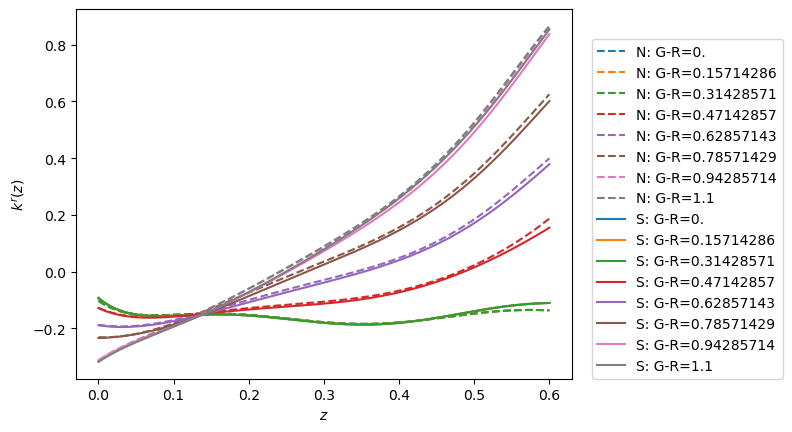

In [4]:
#Plot k-corrections to check they are well behaved
ca.plot_kcorr(regions)

In [8]:
#
if UseBetterSGARedshifts:  #Use the small catalogue for which SGA redshifts appear better than DESI redshifts to replace the DESI redshift
    print('Using some SGA redshifts in place of DESI redshifts')
    sgabetter=Table.read('sdata/SGAbetter.fits')
    sgabetter.info('stats')
    # For objects in the sgabetter table find their match by TARGETID with those in the dat table
    # Unmatched objects have matched=false and indx_sgabetter=-1
    indx_sgabetter,matched=ca.link_indices_by_key(dat,sgabetter, key='TARGETID', assume_unique=True)
    # Replace dat['Z'] for those that match 
    dat['Z'][indx_sgabetter][matched]=sgabetter['Z_LEDA'][indx_sgabetter][matched]


Using some SGA redshifts in place of DESI redshifts
<Table length=147>
  name       mean        std         min         max    
-------- ----------- ----------- ----------- -----------
  Z_LEDA   0.0776161   0.0668794  0.00189798    0.477167
 RA_LEDA     178.349     82.0242     2.19314     358.863
DEC_LEDA     15.1052     23.8627    -16.2975     72.9481
TARGETID 3.96292e+16 2.39482e+12 3.96274e+16 3.96368e+16


In [9]:
#
if PhotometryMatch : #Force absolute magnitude distribution of South to agree with North
   print('Forcing absolute magnitude distribution of South to agree with North')
   dat=ca.remap_rmags(dat,plot=plot)
   # As magnitudes have changed we have to reimpose the selection (we can do this and keep a complete sample if all the shifts make objects fainter)
   Sel=ca.selection('N')# import North selection cuts  
   smaskN= (dat['Z'] > Sel['zmin']) & (dat['Z'] < Sel['zmax']) \
   & (dat['rmag'] < Sel['faint'])  & (dat['rmag'] > Sel['bright']) & (dat['reg']=='N') 
   Sel=ca.selection('S') # import South selection cuts    
   smaskS= (dat['Z'] > Sel['zmin']) & (dat['Z'] < Sel['zmax']) \
   & (dat['rmag'] < Sel['faint'])  & (dat['rmag'] > Sel['bright']) & (dat['reg']=='S')
   smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
   dat=dat[smask]    
   print('South sample size:',smaskS.sum())
   print('North sample size:',smaskN.sum())

Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


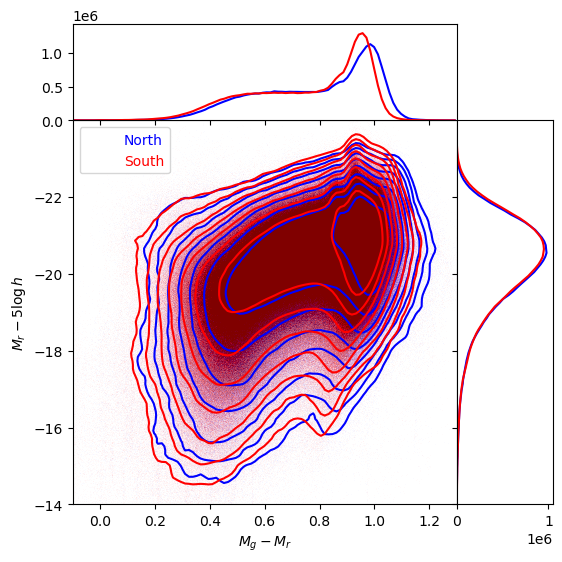

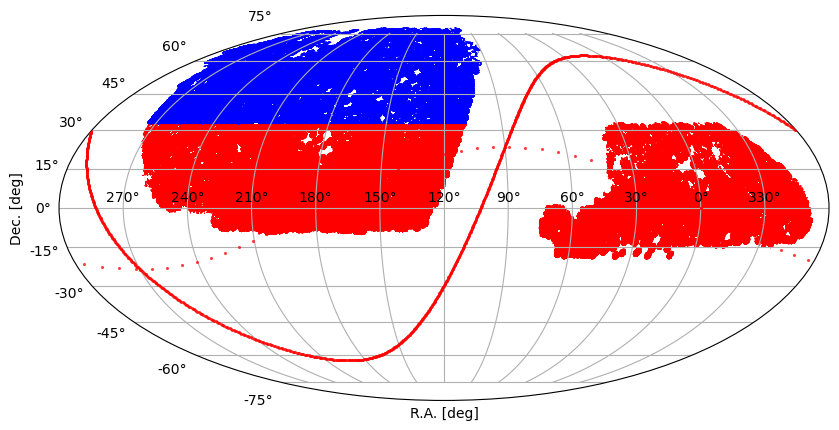

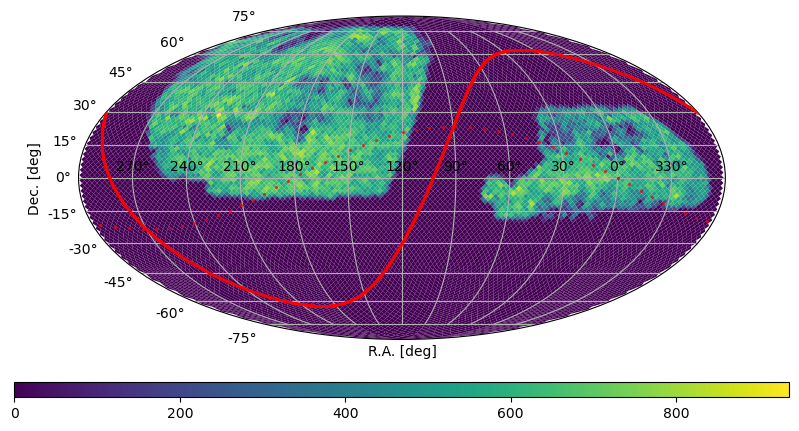

In [10]:
#colour-magnitude distributions
ca.plot_col_mag(dat,regions)
#sky plot
ca.sky_plot(dat,regions)

In [11]:
# Construct the redshift weight table and add the fibmag and TSNR2_BGS columns to the data catalogue
dat=rw.construct_weight_table(dat, observed, zgood, plot=plot)
#Assign redshift incompleteness weights using now pre-computed look-up table
dat.info('stats')
rw.assign_redshift_weight(dat,regions)

starmask= (zgood['Z_not4clus']<0.00125)
print('nstars=',zgood['FLUX_R'][starmask].size,' nstars/ngood=',zgood['FLUX_R'][starmask].size/zgood['FLUX_R'].size)

dat.info('stats')

Number of bins in fibmag and TSNR2_BGS used in weight look-up table. nx,ny: 60 44
number of observed objects in region and covered by the grid 2470201
N : missed and unrepresented objects 21.0
LOOK-UP TABLE GENERATED AND SAVED.
number of observed objects in region and covered by the grid 5509805
S : missed and unrepresented objects 16.0
LOOK-UP TABLE GENERATED AND SAVED.
<Table length=7845183>
      name           mean         std         min          max    
---------------- ------------ ----------- ------------ -----------
        TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
               Z     0.213358    0.104274   0.00200098     0.59999
           NTILE      2.42942    0.916613            1           5
              RA      183.119     91.3102  0.000108207         360
             DEC      21.9893     23.0657     -19.5559     79.2584
         PHOTSYS           --          --           --          --
FRAC_TLOBS_TILES     0.983774   0.0274739     0.333333           1


In [12]:
#Match the dat and observed tables and copy data to add addtional columns to the dat table
len_before=len(dat)
dat = join(dat, observed['TARGETID','MORPHTYPE','EBV','PSFDEPTH_R','GALDEPTH_R','SHAPE_R'], keys='TARGETID')
len_after=len(dat)
if (len_before!=len_after): print('WARNING: dat table changed length when matching from ',length_before,' to ',length_after)


In [13]:
# Compute zmax and vmax values
ca.compute_zmax_vmax(dat,regions)
#  
# Make some test plots but avoid plotting data from any unprocessed region
if (len(regions) > 1):
   regmask=  ((dat['reg']=='N') | (dat['reg']=='S'))
else:    
   regmask= (dat['reg']==regions)

if plot:    
    #Plots of how zmax depends on absolute magnitude, colour and redshift
    ca.plot_zmax_absmag(dat[regmask])
    ca.plot_zmax_z(dat[regmask])
    #Plots of how zmin depends on absolute magnitude, colour and redshift
    ca.plot_zmin_absmag(dat)
    ca.plot_zmin_z(dat[regmask])

starting region  N
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Sample size in this region and between faint and bright apparent magnitude limits: 2429246
This is the right thing to do when zmax computed from the faint limit is greater than the zmax imposed in the sample selection
Similary it is the right thing to if zmin computed from the bright limit is less than the zmin imposed in the sample selection
root_itp2: maximum number of iterations required= 19
iteration 1 : 2404150  not yet converged
iteration 2 : 2404150  not yet converged
iteration 3 : 2403562  not yet converged
iteration 4 : 2194028  not yet converged
iteration 5 : 1362844  not yet converged
iteration 6 : 385960  not yet converged
iteration 7 : 115812  not yet converged
iteration 8 : 57940  not yet converged
iteration 9 : 27956  not yet converged
iteration 10 : 16463  not yet converged
iteration 11 : 11082  not yet converged
iteration 12 : 7671  not yet converged
iteration 13 : 5401  not 

In [14]:
# Write the Augmented table to a fits file 
# Add meta data to store the selection cuts used in defining this sample and other information
Sel=ca.selection('N')
dat.meta['Qevol_N']=Sel['Qevol']
dat.meta['zmax_N']=Sel['zmax']
dat.meta['zmin_N']=Sel['zmin']
dat.meta['bright_N']=Sel['bright']
dat.meta['faint_N']=Sel['faint']
dat.meta['area_N']=Sel['area']
dat.meta['f_ran_N']=Sel['f_ran']
dat.meta['col_N']=Sel['col']
dat.meta['style_N']=Sel['style']

Sel=ca.selection('S')
dat.meta['Qevol_S']=Sel['Qevol']
dat.meta['zmax_S']=Sel['zmax']
dat.meta['zmin_S']=Sel['zmin']
dat.meta['bright_S']=Sel['bright']
dat.meta['faint_S']=Sel['faint']
dat.meta['area_S']=Sel['area']
dat.meta['f_ran_S']=Sel['f_ran']
dat.meta['col_S']=Sel['col']
dat.meta['style_S']=Sel['style']
#
# Store the parameters of the cosmology used to make this catalogue
dat.meta['H0']=ca.cosmo.H0.value
dat.meta['Tcmb0']=ca.cosmo.Tcmb0.value
dat.meta['Om0']=ca.cosmo.Om0
#
# Store the choices made for some of the processing option flags
dat.meta['PMatch']=PhotometryMatch

# Write the table complete with its meta data
#
dat.write('sdata/BGS_Y3_Dec2025All.fits',overwrite=True) 


In [15]:
# quick look at the stats of the final augmented data set
dat.info('stats')

<Table length=7845183>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
                 Z     0.213358    0.104274   0.00200098     0.59999
             NTILE      2.42942    0.916613            1           5
                RA      183.119     91.3102  0.000108207         360
               DEC      21.9893     23.0657     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.983774   0.0274739     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00522281            1     1.19818
        WEIGHT_FKP    0.0481433    0.108808   0.00114216           1
        BITWEIGHTS -3.87208e+14  3.0359e+18 -9.22337e+18 9.22337e+18
          PROB_OBS     0.853817    0.210214            0           1
            WEIGHT      1.30714    0.793713            1      71.376
       WEIG